# CLEF CheckThat! 2026 Task 2 (Arabic) — Full Pipeline + 10-Config MLP Ablation
### Qwen3-Embedding-8B · Attention-pooled traces · Disagreement · Verdict expansion (Raw7 / Dup / AE / Proj) · Kaggle 2×T4

**Pipeline**

`Claim, Reasoning traces → Qwen3-Embedding-8B (last-token pool, L2) → .npz`
`→ [x_claim ; x_attention ; x_disagreement ; x_verdict] → BatchNorm → [Linear→BN→ReLU→Dropout]×3 (512/256/128) → K-way → Softmax`

K = number of gold classes present in the train labels (§4). The Arabic data has no gold "Conflicting", so K = 2 (False/True). "Conflicting" still counts as a trace **vote** inside the verdict features.
`→ class-weighted cross-entropy`

**Ablation (MLP, seed 42)**

| # | Configuration | Claim | Attention | Disagreement | Verdict | Input dim |
|:-:|:--|:-:|:-:|:-:|:--|--:|
| 1 | Full + Raw 7 | ✓ | ✓ | ✓ | Raw 7 | 3·4096+7 = 12295 |
| 2 | Full + Duplication_1024 | ✓ | ✓ | ✓ | Dup 1024 | 13312 |
| 3 | Full + AE_1024 | ✓ | ✓ | ✓ | AE 1024 | 13312 |
| 4 | Full + Projection_1024 | ✓ | ✓ | ✓ | Proj 1024 | 13312 |
| 5 | No_Attention + Duplication_1024 | ✓ | ✗ | ✓ | Dup 1024 | 9216 |
| 6 | No_Attention + AE_1024 | ✓ | ✗ | ✓ | AE 1024 | 9216 |
| 7 | No_Attention + Projection_1024 | ✓ | ✗ | ✓ | Proj 1024 | 9216 |
| 8 | No_Disagreement + Duplication_1024 | ✓ | ✓ | ✗ | Dup 1024 | 9216 |
| 9 | No_Disagreement + AE_1024 | ✓ | ✓ | ✗ | AE 1024 | 9216 |
| 10 | No_Disagreement + Projection_1024 | ✓ | ✓ | ✗ | Proj 1024 | 9216 |

XGBoost is **not** trained in this phase (by decision). Trained MLP weights are saved so the attention/projection layers can be reused later.

---
### How to run on Kaggle (multi-session, resumable)
1. Settings: **GPU T4 ×2**, **Internet ON**. Add the Arabic dataset as input and set `DATA_DIR` in §2.
2. Use **Save Version → Save & Run All (Commit)**. Embedding stops cleanly after `EMBED_TIME_BUDGET_HOURS` so the version finishes and its output (shards) is saved.
3. If §6 reports embeddings are incomplete: open a new version, **add the previous version's output as an input**, and commit again. Shards under `/kaggle/input/**/emb_shards/<EMB_TAG>/` are discovered, validated and copied automatically; only missing shards are embedded.
4. When all three splits are merged, training and evaluation run automatically in the same commit. Finished experiments are skipped on re-runs (`FORCE_RERUN_EXPERIMENTS=False`).

## 1. Environment Setup

In [1]:
# Qwen3 architecture needs transformers >= 4.51
!pip install -q "transformers>=4.51.0" accelerate

In [2]:
import os, gc, re, json, time, glob, math, copy, random, shutil, warnings
from collections import Counter, OrderedDict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                             precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)

print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}")
for _i in range(torch.cuda.device_count()):
    _p = torch.cuda.get_device_properties(_i)
    print(f"  GPU {_i}: {_p.name}  {_p.total_memory/1e9:.1f} GB")

PyTorch      : 2.10.0+cu128
Transformers : 5.0.0
CUDA         : True
  GPU 0: Tesla T4  15.6 GB
  GPU 1: Tesla T4  15.6 GB


## 2. Configuration
Everything that can change a result is set here. Embedding settings are written into every `.npz` as metadata, so shards or files made with different settings are never mixed.

In [3]:
# ─────────────────────────── PATHS ───────────────────────────
DATA_DIR   = "/kaggle/input/REPLACE-WITH-ARABIC-DATASET"      # <- set this
TRAIN_JSON = f"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/Arabic/clef2026_gpt4_o_mini_train_arabic.json"
VAL_JSON   = f"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/Arabic/clef2026_gpt4_o_mini_val_arabic.json"
TEST_JSON  = f"/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/Arabic/clef_arabic_test_gold_labels-final.json"

OUTPUT_DIR         = "/kaggle/working"
RESUME_SEARCH_ROOT = "/kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/qwen3 arabic embeddings"      # searched recursively for earlier shards / merged .npz

# ─────────────────────────── RUN SWITCHES ───────────────────────────
RUN_EMBEDDING           = True
RUN_TRAINING            = True
FORCE_RERUN_EXPERIMENTS = False           # False = skip experiments whose result JSON already exists

# ─────────────────────────── EMBEDDING (Step 2) ───────────────────────────
EMBEDDING_MODEL_ID      = "Qwen/Qwen3-Embedding-8B"
EMB_TAG                 = "qwen3emb8b_ar_v1"   # file/dir tag; change it if you change any embedding setting
MAX_SEQ_LENGTH          = 8192
CLAIM_INSTRUCTION       = None                 # None = raw claim text (same as previous notebooks)
TOKEN_BUDGET            = 16384                # max (batch_size × longest_seq) tokens per forward pass
MAX_TEXTS_PER_BATCH     = 64
SHARD_SIZE              = 64                   # items per resumable shard
EMBED_TIME_BUDGET_HOURS = 11.0                 # stop embedding cleanly before Kaggle's 12 h limit
GPU_MAX_MEMORY          = {0: "12GiB", 1: "12GiB"}   # weights split over 2×T4, headroom left for activations
EMB_STORE_DTYPE         = "float32"
DELETE_SHARDS_AFTER_MERGE = True

# ─────────────────────────── DATA FIELDS ───────────────────────────
CLAIM_FIELD        = "claim"
TRACE_TEXT_FIELD   = "Reasoning_traces"    # capital R — matches the JSON (the old notebooks used a wrong key)
VERDICT_LIST_FIELD = "Verdict_list"
LABEL_KEYS         = ("label", "Label")    # train/val use "label", test uses "Label"
TEST_ID_FIELD      = "query_id"

# label_map = the three verdict VOTE types in Verdict_list (used by the 7 verdict features — always 3 types)
label_map         = {"False": 0, "True": 1, "Conflicting": 2}
reverse_label_map = {v: k for k, v in label_map.items()}

# Classifier TARGET classes. "auto" = the gold classes that actually occur in the TRAIN labels
# (in label_map order). Or give an explicit list, e.g. ["False", "True", "Conflicting"].
# CLASS_NAMES / OUTPUT_DIM are set from this in §4 after the data is loaded.
TARGET_LABELS     = "auto"

# ─────────────────────────── FEATURES / MODEL ───────────────────────────
TRACE_MAX           = 20
SCALAR_DIM          = 7
EXPANDED_SCALAR_DIM = 1024
ATTN_HIDDEN         = 256
PROJ_HIDDEN         = 256
AE_HIDDEN           = 256
HIDDEN_DIMS         = [512, 256, 128]
DROPOUT             = 0.3

# ─────────────────────────── MLP TRAINING ───────────────────────────
BATCH_SIZE          = 16
MAX_EPOCHS          = 100
LEARNING_RATE       = 1e-3
WEIGHT_DECAY        = 1e-5
GRAD_CLIP_NORM      = 1.0
EARLY_STOP_PATIENCE = 20
LR_PLATEAU_FACTOR   = 0.5
LR_PLATEAU_PATIENCE = 3
USE_AMP             = True

# ─────────────────────────── AUTOENCODER PRE-TRAINING ───────────────────────────
AE_EPOCHS     = 200
AE_LR         = 1e-3
AE_BATCH_SIZE = 64

RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS      = torch.cuda.device_count()

# ─────────────────────────── OUTPUT LAYOUT ───────────────────────────
EMB_SHARD_ROOT = f"{OUTPUT_DIR}/emb_shards/{EMB_TAG}"
RESULTS_DIR    = f"{OUTPUT_DIR}/results"
MODELS_DIR     = f"{OUTPUT_DIR}/models"
PLOTS_DIR      = f"{OUTPUT_DIR}/plots"
PREDS_DIR      = f"{OUTPUT_DIR}/predictions"
for _d in [OUTPUT_DIR, EMB_SHARD_ROOT, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, PREDS_DIR]:
    os.makedirs(_d, exist_ok=True)

EMB_META = {
    "tag": EMB_TAG, "model": EMBEDDING_MODEL_ID, "max_seq_length": MAX_SEQ_LENGTH,
    "claim_instruction": CLAIM_INSTRUCTION, "pooling": "last_token", "l2_normalized": True,
    "store_dtype": EMB_STORE_DTYPE, "trace_field": TRACE_TEXT_FIELD,
    "row_layout": "row0=claim, rows1..n=non-empty reasoning traces in original order",
}
print(json.dumps(EMB_META, indent=2, ensure_ascii=False))
print(f"Device: {DEVICE} ({N_GPUS} GPU)")

{
  "tag": "qwen3emb8b_ar_v1",
  "model": "Qwen/Qwen3-Embedding-8B",
  "max_seq_length": 8192,
  "claim_instruction": null,
  "pooling": "last_token",
  "l2_normalized": true,
  "store_dtype": "float32",
  "trace_field": "Reasoning_traces",
  "row_layout": "row0=claim, rows1..n=non-empty reasoning traces in original order"
}
Device: cuda (2 GPU)


## 3. Reproducibility

In [4]:
def set_seed(seed: int = RANDOM_SEED) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()

def to_py(obj):
    if isinstance(obj, np.integer):  return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray):  return obj.tolist()
    if isinstance(obj, dict):        return {str(k): to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [to_py(v) for v in obj]
    return obj

with open(f"{OUTPUT_DIR}/experiment_meta.json", "w") as _f:
    json.dump(to_py({k: v for k, v in globals().items()
                     if k.isupper() and isinstance(v, (int, float, str, bool, list, dict, type(None)))}),
              _f, indent=2, ensure_ascii=False)
print(f"Seed {RANDOM_SEED} | config saved → {OUTPUT_DIR}/experiment_meta.json")

Seed 42 | config saved → /kaggle/working/experiment_meta.json


## 4. Dataset Loading & Schema Validation
IDs: train and validation use the position in the file (0..N-1); test uses `query_id`. The run stops with a clear error if a record is malformed (for example `Reasoning_traces` not being a list of strings, or a label outside `label_map`). It does not guess.

In [5]:
def load_json(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found — set DATA_DIR in §2")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def get_label_name(item):
    for k in LABEL_KEYS:
        if k in item:
            v = item[k]
            if v not in label_map:
                raise ValueError(f"Unknown label {v!r} (expected one of {list(label_map)})")
            return v
    raise KeyError(f"No label key {LABEL_KEYS} in item with keys {list(item.keys())}")

def get_target(item):
    # Gold label → classifier index in the active target space (set below)
    name = get_label_name(item)
    if name not in TARGET_INDEX:
        raise ValueError(f"Gold label {name!r} is not in the target classes {CLASS_NAMES}")
    return TARGET_INDEX[name]

def get_trace_texts(item):
    # Non-empty reasoning traces, original order. Empty/whitespace traces are dropped (and counted in §5).
    return [t for t in item[TRACE_TEXT_FIELD] if t.strip()]

def validate_items(items, split):
    errors = []
    for i, it in enumerate(items):
        if not isinstance(it.get(CLAIM_FIELD), str):
            errors.append(f"[{split}#{i}] '{CLAIM_FIELD}' missing or not a string")
        tr = it.get(TRACE_TEXT_FIELD)
        if not isinstance(tr, list) or not all(isinstance(t, str) for t in tr):
            errors.append(f"[{split}#{i}] '{TRACE_TEXT_FIELD}' must be a list of strings, got {type(tr).__name__}")
        vl = it.get(VERDICT_LIST_FIELD)
        if not isinstance(vl, list):
            errors.append(f"[{split}#{i}] '{VERDICT_LIST_FIELD}' must be a list, got {type(vl).__name__}")
        try: get_label_name(it)
        except Exception as e: errors.append(f"[{split}#{i}] {e}")
        if len(errors) >= 20: break
    if errors:
        raise ValueError(f"{split}: schema errors (first {len(errors)}):\n  " + "\n  ".join(errors))

def build_split(items, split, id_mode):
    validate_items(items, split)
    if id_mode == "index":
        ids = list(range(len(items)))
    elif id_mode == "query_id":
        ids = [it[TEST_ID_FIELD] for it in items]
        if len(set(ids)) != len(ids):
            raise ValueError(f"{split}: duplicate {TEST_ID_FIELD} values")
    else:
        raise ValueError(id_mode)
    id_to_item = dict(zip(ids, items))
    return {"name": split, "id_to_item": id_to_item, "order": sorted(ids)}

SPLITS = OrderedDict()
SPLITS["train"] = build_split(load_json(TRAIN_JSON), "train", "index")
SPLITS["val"]   = build_split(load_json(VAL_JSON),   "val",   "index")
SPLITS["test"]  = build_split(load_json(TEST_JSON),  "test",  "query_id")

for s, d in SPLITS.items():
    first = d["id_to_item"][d["order"][0]]
    print(f"{s:<5}: {len(d['order']):>6} items | keys={list(first.keys())}")
print("✓ Schema valid for all splits")

# ── Target label space ─────────────────────────────────────────────────────
GOLD_COUNTS = {s: Counter(get_label_name(it) for it in d["id_to_item"].values()) for s, d in SPLITS.items()}
if TARGET_LABELS == "auto":
    CLASS_NAMES = [n for n in label_map if GOLD_COUNTS["train"][n] > 0]
else:
    CLASS_NAMES = list(TARGET_LABELS)
    missing = [n for n in CLASS_NAMES if GOLD_COUNTS["train"][n] == 0]
    if missing:
        raise ValueError(f"TARGET_LABELS contains classes with 0 train examples: {missing} — "
                         f"they cannot be learned or class-weighted. Use TARGET_LABELS='auto'.")
TARGET_INDEX = {n: i for i, n in enumerate(CLASS_NAMES)}
OUTPUT_DIM   = len(CLASS_NAMES)
TARGET_IDS   = list(range(OUTPUT_DIM))
if OUTPUT_DIM < 2:
    raise ValueError(f"Only {OUTPUT_DIM} gold class in train — nothing to classify")
for s, c in GOLD_COUNTS.items():
    extra = [n for n in c if n not in TARGET_INDEX]
    if extra:
        raise ValueError(f"{s} has gold labels {extra} that never occur in train — cannot be predicted")

print("\nGold label counts:")
display(pd.DataFrame({s: {n: c[n] for n in label_map} for s, c in GOLD_COUNTS.items()}))
dropped = [n for n in label_map if n not in TARGET_INDEX]
print(f"Target classes ({OUTPUT_DIM}-way head): {CLASS_NAMES}")
if dropped:
    print(f"⚠ Not a target (0 gold examples in train): {dropped}. These still count as VOTES in the "
          f"verdict features; they are excluded from the head, the class weights and Macro-F1.")
with open(f"{OUTPUT_DIR}/label_space.json", "w") as _f:
    json.dump({"target_classes": CLASS_NAMES, "not_targets": dropped,
               "gold_counts": {s: dict(c) for s, c in GOLD_COUNTS.items()}}, _f, indent=2)

train:   2608 items | keys=['Reasoning_traces', 'Verdict_list', 'claim', 'evidences', 'label', 'verdict']
val  :    652 items | keys=['Reasoning_traces', 'Verdict_list', 'claim', 'evidences', 'label', 'verdict']
test :    511 items | keys=['Reasoning_traces', 'Verdict_list', 'claim', 'evidences', 'Label', 'verdict', 'query_id']
✓ Schema valid for all splits

Gold label counts:


,train,val,test
False,1444,361,318
True,1164,291,193
Conflicting,0,0,0


Target classes (2-way head): ['False', 'True']
⚠ Not a target (0 gold examples in train): ['Conflicting']. These still count as VOTES in the verdict features; they are excluded from the head, the class weights and Macro-F1.


## 5. Data Diagnostics
These checks run **before** any compute is spent. They report trace counts, verdict-list values (including any value outside `True`/`False`/`Conflicting`, which would silently zero the verdict features), rows whose verdict features would be all zero, label balance, and a *diagnostic-only* reference: the plurality vote of `Verdict_list` (a tie, or a vote for a class that is not a target, counts as an error).

If one split looks very different from the others here (for example val), the model's behaviour on that split will too.

In [6]:
def data_diagnostics(d):
    items = [d["id_to_item"][i] for i in d["order"]]
    n_tr_raw   = np.array([len(it[TRACE_TEXT_FIELD]) for it in items])
    n_tr_valid = np.array([len(get_trace_texts(it)) for it in items])
    n_vl       = np.array([len(it[VERDICT_LIST_FIELD]) for it in items])
    vals       = Counter(v for it in items for v in it[VERDICT_LIST_FIELD])
    unknown    = {k: c for k, c in vals.items() if k not in label_map}
    known_cnt  = np.array([sum(v in label_map for v in it[VERDICT_LIST_FIELD]) for it in items])
    labels     = np.array([get_target(it) for it in items])

    # plurality vote → target index; a tie or a vote for a non-target class counts as wrong (-1)
    plural = []
    for it in items:
        c = Counter(v for v in it[VERDICT_LIST_FIELD] if v in label_map)
        top = c.most_common()
        if not top or (len(top) > 1 and top[0][1] == top[1][1]): plural.append(-1); continue
        plural.append(TARGET_INDEX.get(top[0][0], -1))
    plural = np.array(plural)

    return {
        "items": len(items),
        "traces min/mean/max": f"{n_tr_raw.min()}/{n_tr_raw.mean():.2f}/{n_tr_raw.max()}",
        "empty traces dropped": int((n_tr_raw - n_tr_valid).sum()),
        "items with 0 traces": int((n_tr_valid == 0).sum()),
        f"items > TRACE_MAX({TRACE_MAX})": int((n_tr_valid > TRACE_MAX).sum()),
        "len(traces)≠len(verdicts)": int((n_tr_raw != n_vl).sum()),
        "verdict values": dict(vals),
        "UNKNOWN verdict values": unknown,
        "all-zero verdict feats": int((known_cnt == 0).sum()),
        f"label dist {CLASS_NAMES}": [int((labels == c).sum()) for c in TARGET_IDS],
        "plurality-vote Macro-F1": round(f1_score(labels, plural, average="macro", labels=TARGET_IDS, zero_division=0), 4),
        "plurality-vote Acc": round(accuracy_score(labels, plural), 4),
    }

DATA_DIAG = {s: data_diagnostics(d) for s, d in SPLITS.items()}
display(pd.DataFrame(DATA_DIAG))

for s, dg in DATA_DIAG.items():
    if dg["UNKNOWN verdict values"]:
        print(f"⚠ {s}: verdict values outside label_map are IGNORED by verdict_features: {dg['UNKNOWN verdict values']}")
    if dg["all-zero verdict feats"]:
        print(f"⚠ {s}: {dg['all-zero verdict feats']} items will get an all-zero 7-dim verdict vector")
    if dg["items with 0 traces"]:
        print(f"⚠ {s}: {dg['items with 0 traces']} items have no non-empty trace (attention/disagreement → zero vector)")
with open(f"{OUTPUT_DIR}/data_diagnostics.json", "w") as _f:
    json.dump(to_py(DATA_DIAG), _f, indent=2, ensure_ascii=False)

,train,val,test
items,2608,652,511
traces min/mean/max,20/20.00/20,20/20.00/20,20/20.00/20
empty traces dropped,0,0,0
items with 0 traces,0,0,0
items > TRACE_MAX(20),0,0,0
len(traces)≠len(verdicts),0,0,0
verdict values,"{'True': 21626, 'Conflicting': 5813, 'False': ...","{'False': 6193, 'True': 5457, 'Conflicting': 1...","{'True': 5272, 'False': 4166, 'Conflicting': 782}"
UNKNOWN verdict values,{},{},{}
all-zero verdict feats,0,0,0
"label dist ['False', 'True']","[1444, 1164]","[361, 291]","[318, 193]"


## 6. Qwen3-Embedding-8B — Resumable Embedding Generation (Step 2)
* **Pooling:** last token with **left padding** and an end-of-text token at the end of every sequence (the official Qwen3-Embedding recipe), then L2 normalisation. The EOS check below confirms this for the tokenizer you actually download.
* **Throughput:** each shard's texts (claims and traces) are sorted by length and packed into token-budgeted batches with `use_cache=False`. The fp16 weights are split across both T4s (`device_map="auto"`).
* **Safety:** an out-of-memory error splits the batch in half and retries. Any non-finite embedding is re-computed alone, and the run **stops** if it is still non-finite, rather than storing a bad vector.
* **Storage:** each item is stored as `id_<id>` → `(1 + n_traces, 4096)`, with row 0 = claim and rows 1.. = traces. `__ids__` and `__meta__` are also stored. Shards are written atomically. When a split is complete, its shards are merged into `/kaggle/working/<split>_<EMB_TAG>.npz`.

In [7]:
def split_shards(split):
    order = SPLITS[split]["order"]
    return [(k, order[k*SHARD_SIZE:(k+1)*SHARD_SIZE]) for k in range(math.ceil(len(order) / SHARD_SIZE))]

def shard_path(split, k):   return f"{EMB_SHARD_ROOT}/{split}/shard_{k:05d}.npz"
def final_npz_name(split):  return f"{split}_{EMB_TAG}.npz"
def final_npz_path(split):  return f"{OUTPUT_DIR}/{final_npz_name(split)}"

def _meta_ok(npz):
    return "__meta__" in npz.files and json.loads(str(npz["__meta__"])) == EMB_META

def check_npz(path, expected_ids, deep=True):
    # True iff the file has matching meta, exactly the expected ids and (deep) finite 2-D arrays with ≥1 row.
    try:
        with np.load(path, allow_pickle=False) as z:
            if not _meta_ok(z): return False
            if list(z["__ids__"]) != [str(i) for i in expected_ids]: return False
            if deep:
                for i in expected_ids:
                    a = z[f"id_{i}"]
                    if a.ndim != 2 or a.shape[0] < 1 or not np.isfinite(a).all(): return False
        return True
    except Exception as e:
        print(f"  ! unreadable {path}: {e}")
        return False

def save_npz_atomic(path, arrays, ids):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path[:-4] + ".tmp.npz"
    np.savez(tmp, __meta__=np.array(json.dumps(EMB_META, ensure_ascii=False)),
             __ids__=np.array([str(i) for i in ids]), **arrays)
    os.replace(tmp, path)

def import_previous_embeddings():
    # Find merged files / shards from earlier Kaggle versions under RESUME_SEARCH_ROOT; validate and reuse.
    final_paths, copied = {}, 0
    search = os.path.isdir(RESUME_SEARCH_ROOT)
    for split in SPLITS:
        order = SPLITS[split]["order"]
        if os.path.exists(final_npz_path(split)) and check_npz(final_npz_path(split), order, deep=False):
            final_paths[split] = final_npz_path(split); continue
        if not search: continue
        for p in glob.glob(f"{RESUME_SEARCH_ROOT}/**/{final_npz_name(split)}", recursive=True):
            if check_npz(p, order, deep=False):
                final_paths[split] = p; print(f"[{split}] merged embeddings found → {p}"); break
        if split in final_paths: continue
        expected = dict(split_shards(split))
        for p in glob.glob(f"{RESUME_SEARCH_ROOT}/**/emb_shards/{EMB_TAG}/{split}/shard_*.npz", recursive=True):
            m = re.search(r"shard_(\d+)\.npz$", p)
            if not m: continue
            k = int(m.group(1)); dst = shard_path(split, k)
            if k in expected and not os.path.exists(dst) and check_npz(p, expected[k]):
                os.makedirs(os.path.dirname(dst), exist_ok=True); shutil.copy(p, dst); copied += 1
    print(f"Imported {copied} shard(s) from {RESUME_SEARCH_ROOT}")
    return final_paths

def embedding_status(final_paths):
    status = {}
    for split in SPLITS:
        if split in final_paths:
            status[split] = "merged"; continue
        shards = split_shards(split)
        done = sum(os.path.exists(shard_path(split, k)) for k, _ in shards)
        status[split] = f"{done}/{len(shards)} shards"
    return status

FINAL_EMB_PATHS = import_previous_embeddings() if RUN_EMBEDDING or RUN_TRAINING else {}
print("Embedding status:", embedding_status(FINAL_EMB_PATHS))

[train] merged embeddings found → /kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/qwen3 arabic embeddings/train_qwen3emb8b_ar_v1.npz
[val] merged embeddings found → /kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/qwen3 arabic embeddings/val_qwen3emb8b_ar_v1.npz
[test] merged embeddings found → /kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/qwen3 arabic embeddings/test_qwen3emb8b_ar_v1.npz
Imported 0 shard(s) from /kaggle/input/datasets/d202511054/clef-2026-checkthat-task-2-data/qwen3 arabic embeddings
Embedding status: {'train': 'merged', 'val': 'merged', 'test': 'merged'}


In [8]:
# ── Embedding helpers (official Qwen3-Embedding last-token pooling) ─────────────
def last_token_pool(last_hidden_states, attention_mask):
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return last_hidden_states[:, -1]
    seq_len = attention_mask.sum(dim=1) - 1
    return last_hidden_states[torch.arange(last_hidden_states.shape[0], device=last_hidden_states.device), seq_len]

def format_claim(text):
    text = text.strip()
    return text if CLAIM_INSTRUCTION is None else f"Instruct: {CLAIM_INSTRUCTION}\nQuery:{text}"

def detect_eos_mode(tok):
    # 'auto'   : the tokenizer itself appends a trailing special token (official Qwen3-Embedding behaviour) → use as-is
    # 'manual' : nothing is appended → we append <|endoftext|> (or eos) so the last position is an end token
    probe = "تحقق test"
    with_sp = tok([probe], truncation=True, max_length=MAX_SEQ_LENGTH)["input_ids"][0]
    plain   = tok([probe], add_special_tokens=False)["input_ids"][0]
    if len(with_sp) > len(plain) and with_sp[:len(plain)] == plain:
        return "auto", with_sp[-1]
    vocab = tok.get_vocab()
    end_id = vocab.get("<|endoftext|>", tok.eos_token_id)
    if end_id is None:
        raise ValueError("Tokenizer appends no end token and has no <|endoftext|>/eos — cannot last-token pool safely")
    return "manual", end_id

def tokenize_texts(tok, texts, eos_mode):
    mode, end_id = eos_mode
    if mode == "auto":
        return tok(texts, truncation=True, max_length=MAX_SEQ_LENGTH)["input_ids"]
    ids = tok(texts, truncation=True, max_length=MAX_SEQ_LENGTH - 1)["input_ids"]
    return [x + [end_id] for x in ids]

def make_batches(lengths):
    order = sorted(range(len(lengths)), key=lambda i: -lengths[i])
    batches, cur, cur_max = [], [], 0
    for i in order:
        new_max = max(cur_max, lengths[i])
        if cur and (new_max * (len(cur) + 1) > TOKEN_BUDGET or len(cur) >= MAX_TEXTS_PER_BATCH):
            batches.append(cur); cur, new_max = [], lengths[i]
        cur.append(i); cur_max = new_max
    if cur: batches.append(cur)
    return batches

@torch.no_grad()
def _forward(model, tok, id_lists):
    enc = tok.pad({"input_ids": id_lists}, padding=True, return_tensors="pt")
    dev = model.get_input_embeddings().weight.device
    out = model(input_ids=enc["input_ids"].to(dev), attention_mask=enc["attention_mask"].to(dev), use_cache=False)
    h   = out.last_hidden_state
    emb = last_token_pool(h, enc["attention_mask"].to(h.device)).float()
    finite = torch.isfinite(emb).all(dim=1)
    emb = F.normalize(emb, p=2, dim=-1)
    return emb.cpu().numpy(), finite.cpu().numpy()

def encode_ids(model, tok, id_lists):
    try:
        emb, finite = _forward(model, tok, id_lists)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        if len(id_lists) == 1:
            raise RuntimeError(f"OOM on a single sequence of {len(id_lists[0])} tokens — "
                               f"lower MAX_SEQ_LENGTH or TOKEN_BUDGET, or adjust GPU_MAX_MEMORY")
        h = len(id_lists) // 2
        return np.concatenate([encode_ids(model, tok, id_lists[:h]), encode_ids(model, tok, id_lists[h:])])
    if not finite.all():
        for j in np.where(~finite)[0]:
            e1, f1 = _forward(model, tok, [id_lists[j]])
            if not f1.all():
                raise RuntimeError(f"Non-finite embedding for a {len(id_lists[j])}-token text even when encoded "
                                   f"alone (fp16 overflow). Stopping instead of storing a corrupt vector.")
            emb[j] = e1[0]
    return emb

def embed_shard(model, tok, eos_mode, split, ids, emb_dim):
    texts, owners = [], []
    for id_ in ids:
        it = SPLITS[split]["id_to_item"][id_]
        texts.append(format_claim(it[CLAIM_FIELD])); owners.append(id_)
        for t in get_trace_texts(it):
            texts.append(t); owners.append(id_)
    id_lists = tokenize_texts(tok, texts, eos_mode)
    lengths  = [len(x) for x in id_lists]
    out = np.empty((len(texts), emb_dim), dtype=np.float32)
    for b in make_batches(lengths):
        out[b] = encode_ids(model, tok, [id_lists[i] for i in b])
    arrays, pos = {}, 0
    for id_ in ids:
        n = owners.count(id_)       # contiguous block: claim + its traces
        arrays[f"id_{id_}"] = out[pos:pos+n].astype(EMB_STORE_DTYPE); pos += n
    n_trunc = sum(l >= MAX_SEQ_LENGTH for l in lengths)
    return arrays, len(texts), sum(lengths), n_trunc

In [9]:
def all_splits_merged():
    return all(s in FINAL_EMB_PATHS for s in SPLITS)

EMB_MODEL = EMB_TOK = None
EOS_MODE = None
EMB_DIM = None

if RUN_EMBEDDING and not all_splits_merged():
    print(f"Loading tokenizer: {EMBEDDING_MODEL_ID}")
    EMB_TOK = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_ID, padding_side="left")
    EMB_TOK.padding_side = "left"
    if EMB_TOK.pad_token_id is None:
        EMB_TOK.pad_token = EMB_TOK.eos_token
    EOS_MODE = detect_eos_mode(EMB_TOK)
    print(f"  eos_token={EMB_TOK.eos_token!r} | pad={EMB_TOK.pad_token!r} | padding_side={EMB_TOK.padding_side}")
    print(f"  end-token mode = {EOS_MODE[0]} | last token = {EMB_TOK.convert_ids_to_tokens(EOS_MODE[1])!r} "
          f"(id {EOS_MODE[1]}) — pooled position")

    print(f"Loading model: {EMBEDDING_MODEL_ID}")
    if torch.cuda.is_available():
        EMB_MODEL = AutoModel.from_pretrained(
            EMBEDDING_MODEL_ID, torch_dtype=torch.float16, device_map="auto",
            max_memory={k: v for k, v in GPU_MAX_MEMORY.items() if k < N_GPUS},
            attn_implementation="sdpa")
    else:
        EMB_MODEL = AutoModel.from_pretrained(EMBEDDING_MODEL_ID, torch_dtype=torch.float32)
    EMB_MODEL.eval()
    EMB_DIM = EMB_MODEL.config.hidden_size
    print(f"  hidden_size = {EMB_DIM}")
    if hasattr(EMB_MODEL, "hf_device_map"):
        print(f"  device map: {Counter(str(v) for v in EMB_MODEL.hf_device_map.values())}")

    # Sanity: a claim and a trace from the train set encode to finite unit vectors
    _it = SPLITS["train"]["id_to_item"][SPLITS["train"]["order"][0]]
    _probe = encode_ids(EMB_MODEL, EMB_TOK,
                        tokenize_texts(EMB_TOK, [format_claim(_it[CLAIM_FIELD])] + get_trace_texts(_it)[:1], EOS_MODE))
    print(f"  probe: shape={_probe.shape} norms={np.linalg.norm(_probe, axis=1).round(4)} "
          f"cos(claim,trace)={float(_probe[0] @ _probe[1]) if len(_probe) > 1 else float('nan'):.4f}")
else:
    print("Embedding model not needed (all splits already merged, or RUN_EMBEDDING=False).")

Embedding model not needed (all splits already merged, or RUN_EMBEDDING=False).


In [10]:
def run_embedding():
    t_start, budget = time.time(), EMBED_TIME_BUDGET_HOURS * 3600
    for split in SPLITS:
        if split in FINAL_EMB_PATHS:
            print(f"[{split}] already merged — skip"); continue
        shards = split_shards(split)
        todo = [(k, ids) for k, ids in shards if not os.path.exists(shard_path(split, k))]
        print(f"\n[{split}] {len(shards) - len(todo)}/{len(shards)} shards done, {len(todo)} to embed")
        t_split, n_items_done = time.time(), 0
        for j, (k, ids) in enumerate(todo):
            if time.time() - t_start > budget:
                print(f"\n⏸ Time budget of {EMBED_TIME_BUDGET_HOURS} h reached — stopping cleanly. "
                      f"Commit this version, add its output as input, and run again to resume.")
                return False
            arrays, n_txt, n_tok, n_trunc = embed_shard(EMB_MODEL, EMB_TOK, EOS_MODE, split, ids, EMB_DIM)
            save_npz_atomic(shard_path(split, k), arrays, ids)
            n_items_done += len(ids)
            if j % 10 == 0 or j == len(todo) - 1:
                el = time.time() - t_split
                rate = n_items_done / max(el, 1e-9)
                left = sum(len(x) for _, x in todo[j+1:])
                print(f"  shard {k:05d} | {n_txt} texts, {n_tok} tok, {n_trunc} truncated | "
                      f"{rate:.2f} items/s | split ETA {left / max(rate, 1e-9) / 60:.1f} min | "
                      f"elapsed {(time.time() - t_start) / 3600:.2f} h")
    return True

def merge_split(split):
    order, arrays = SPLITS[split]["order"], {}
    for k, ids in split_shards(split):
        p = shard_path(split, k)
        if not check_npz(p, ids):
            raise RuntimeError(f"Shard {p} is invalid — delete it and re-run embedding")
        with np.load(p, allow_pickle=False) as z:
            for i in ids:
                arrays[f"id_{i}"] = z[f"id_{i}"]
    save_npz_atomic(final_npz_path(split), arrays, order)
    if not check_npz(final_npz_path(split), order, deep=True):
        raise RuntimeError(f"Merged file {final_npz_path(split)} failed verification")
    FINAL_EMB_PATHS[split] = final_npz_path(split)
    if DELETE_SHARDS_AFTER_MERGE:
        shutil.rmtree(f"{EMB_SHARD_ROOT}/{split}", ignore_errors=True)
    print(f"[{split}] merged {len(order)} items → {final_npz_path(split)} "
          f"({os.path.getsize(final_npz_path(split)) / 1e9:.2f} GB)")

if RUN_EMBEDDING and not all_splits_merged():
    _finished = run_embedding()
    for split in SPLITS:
        if split not in FINAL_EMB_PATHS and all(os.path.exists(shard_path(split, k)) for k, _ in split_shards(split)):
            merge_split(split)

EMBEDDINGS_READY = all_splits_merged()
print("\nEmbedding status:", embedding_status(FINAL_EMB_PATHS))
print("EMBEDDINGS_READY =", EMBEDDINGS_READY)
if not EMBEDDINGS_READY:
    print("→ Training cells below will be skipped in this session.")

# free the 8B model before training
EMB_MODEL = None
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


Embedding status: {'train': 'merged', 'val': 'merged', 'test': 'merged'}
EMBEDDINGS_READY = True


### 6.1 Embedding Verification
This check catches the failure in the earlier notebooks, where every item had a single `[NO TRACE]` row. For each item, the number of trace rows must equal the number of non-empty `Reasoning_traces` in the JSON. It also checks unit norms, finiteness, and that the traces of an item are not all identical.

In [11]:
EMB = {}
if EMBEDDINGS_READY:
    for split in SPLITS:
        with np.load(FINAL_EMB_PATHS[split], allow_pickle=False) as z:
            if not _meta_ok(z):
                raise RuntimeError(f"{FINAL_EMB_PATHS[split]}: metadata does not match EMB_META")
            EMB[split] = {k: z[k] for k in z.files if k.startswith("id_")}

    dims = {a.shape[1] for s in EMB for a in EMB[s].values()}
    assert len(dims) == 1, f"Inconsistent embedding dims: {dims}"
    EMB_DIM = dims.pop()

    rows = {}
    for split, d in SPLITS.items():
        n_bad_count, norms, spreads, identical = 0, [], [], 0
        for id_ in d["order"]:
            a = EMB[split][f"id_{id_}"]
            if a.shape[0] - 1 != len(get_trace_texts(d["id_to_item"][id_])): n_bad_count += 1
            norms.append(np.linalg.norm(a, axis=1))
            if a.shape[0] > 2:
                sd = a[1:].std(axis=0).mean(); spreads.append(sd); identical += sd < 1e-6
        norms = np.concatenate(norms)
        rows[split] = {"items": len(d["order"]), "dim": EMB_DIM,
                       "trace-count mismatches": n_bad_count,
                       "norm min/max": f"{norms.min():.4f}/{norms.max():.4f}",
                       "mean within-item trace std": f"{np.mean(spreads):.5f}" if spreads else "n/a",
                       "items with identical traces": int(identical)}
        assert n_bad_count == 0, f"{split}: {n_bad_count} items have a trace count different from the JSON"
        assert np.allclose(norms, 1.0, atol=1e-3), f"{split}: embeddings are not unit-norm"
    display(pd.DataFrame(rows))
    print(f"✓ Embeddings verified | EMB_DIM = {EMB_DIM}")
else:
    print("Skipped — embeddings not complete yet.")

,train,val,test
items,2608,652,511
dim,4096,4096,4096
trace-count mismatches,0,0,0
norm min/max,1.0000/1.0000,1.0000/1.0000,1.0000/1.0000
mean within-item trace std,0.00326,0.00324,0.00350
items with identical traces,0,0,0


✓ Embeddings verified | EMB_DIM = 4096


## 7. Feature Engineering (Step 3)
`split_and_pad` and `verdict_features` are carried over **unchanged** from the reference notebook.

| idx | verdict feature | description |
|:-:|:--|:--|
| 0–2 | frac_false / frac_true / frac_conflicting | vote shares |
| 3 | majority_frac | plurality share |
| 4 | distinct_ratio | classes with ≥ 1 vote / 3 |
| 5 | entropy | Shannon entropy of vote shares |
| 6 | num_traces_norm | min(valid votes / TRACE_MAX, 1) |

Everything is pre-stacked into tensors once: claim `(N,D)`, traces `(N,20,D)`, mask `(N,20)`, verdict `(N,7)` and label `(N,)`.

In [12]:
def split_and_pad(emb_array, max_traces=None, emb_dim=None):
    # Row 0 = claim, rows 1+ = traces. Zero-pad traces to TRACE_MAX (truncate beyond).
    if max_traces is None: max_traces = TRACE_MAX
    if emb_dim    is None: emb_dim    = EMB_DIM
    claim_emb = emb_array[0].astype(np.float32)
    traces    = emb_array[1:].astype(np.float32)
    n         = traces.shape[0]
    mask      = np.zeros(max_traces, dtype=np.float32)
    if n < max_traces:
        traces_padded = np.vstack([traces, np.zeros((max_traces - n, emb_dim), dtype=np.float32)])
        mask[:n] = 1.0
    else:
        traces_padded = traces[:max_traces]
        mask[:max_traces] = 1.0
    return claim_emb, traces_padded, mask

def verdict_features(verdict_list, max_traces=None):
    # 7 scalar features from the per-trace vote distribution (unchanged from the reference notebook).
    if max_traces is None: max_traces = TRACE_MAX
    counts = {0: 0, 1: 0, 2: 0}
    for v in verdict_list:
        if v in label_map:
            counts[label_map[v]] += 1
    total = sum(counts.values())
    if total == 0:
        return np.zeros(SCALAR_DIM, dtype=np.float32)
    frac_false, frac_true, frac_conf = counts[0] / total, counts[1] / total, counts[2] / total
    majority_frac   = max(counts.values()) / total
    distinct_ratio  = sum(1 for c in counts.values() if c > 0) / 3.0
    entropy         = -sum(p * np.log(p + 1e-9) for p in [frac_false, frac_true, frac_conf] if p > 0)
    num_traces_norm = min(total / max_traces, 1.0)
    return np.array([frac_false, frac_true, frac_conf, majority_frac, distinct_ratio, entropy, num_traces_norm],
                    dtype=np.float32)

def build_arrays(split):
    d, N = SPLITS[split], len(SPLITS[split]["order"])
    claims  = np.empty((N, EMB_DIM), dtype=np.float32)
    traces  = np.empty((N, TRACE_MAX, EMB_DIM), dtype=np.float32)
    masks   = np.empty((N, TRACE_MAX), dtype=np.float32)
    scalars = np.empty((N, SCALAR_DIM), dtype=np.float32)
    labels  = np.empty((N,), dtype=np.int64)
    for r, id_ in enumerate(d["order"]):
        it = d["id_to_item"][id_]
        claims[r], traces[r], masks[r] = split_and_pad(EMB[split][f"id_{id_}"])
        scalars[r] = verdict_features(it[VERDICT_LIST_FIELD])
        labels[r]  = get_target(it)
    return {"ids": list(d["order"]), "claim": torch.from_numpy(claims), "traces": torch.from_numpy(traces),
            "mask": torch.from_numpy(masks), "scalars": torch.from_numpy(scalars), "labels": torch.from_numpy(labels)}

ARR = {}
if EMBEDDINGS_READY:
    for split in SPLITS:
        ARR[split] = build_arrays(split)
        del EMB[split]; gc.collect()
    feat_rows = {}
    for split, a in ARR.items():
        sc = a["scalars"].numpy(); nt = a["mask"].sum(1).numpy()
        feat_rows[split] = {"N": len(a["ids"]), "traces used mean": f"{nt.mean():.2f}",
                            "items with 0 traces": int((nt == 0).sum()),
                            "all-zero verdict rows": int((np.abs(sc).sum(1) == 0).sum()),
                            **{f"mean {n}": f"{sc[:, i].mean():.3f}" for i, n in enumerate(
                               ["fFalse", "fTrue", "fConf", "major", "distinct", "entropy", "nTr"])}}
    display(pd.DataFrame(feat_rows))
    _cnt = Counter(ARR["train"]["labels"].tolist())
    assert all(_cnt[c] > 0 for c in TARGET_IDS), f"Empty target class in train: {_cnt}"
    # w_c = N / (K · n_c), K = number of target classes
    class_weights = torch.tensor([len(ARR["train"]["ids"]) / (OUTPUT_DIM * _cnt[c]) for c in TARGET_IDS],
                                 dtype=torch.float32)
    print("Train label counts:", {CLASS_NAMES[c]: _cnt[c] for c in TARGET_IDS})
    print("Class weights     :", [round(w, 4) for w in class_weights.tolist()])
else:
    print("Skipped — embeddings not complete yet.")

,train,val,test
N,2608,652,511
traces used mean,20.00,20.00,20.00
items with 0 traces,0,0,0
all-zero verdict rows,0,0,0
mean fFalse,0.474,0.475,0.408
mean fTrue,0.415,0.418,0.516
mean fConf,0.111,0.107,0.077
mean major,0.907,0.910,0.881
mean distinct,0.505,0.497,0.531
mean entropy,0.212,0.203,0.257


Train label counts: {'False': 1444, 'True': 1164}
Class weights     : [0.903, 1.1203]


## 8. Model Components (Steps 3–6)
* **AttentionPool**: additive attention `Linear(D,256)→Tanh→Linear(256,1)`, masked softmax, weighted sum. This is identical to the reference notebook, plus one guard: an item with no valid trace gets a zero vector instead of NaN.
* **masked_std**: element-wise standard deviation over valid traces (disagreement). Unchanged.
* **Verdict representations** (7 → 1024):
  * **Raw7**: the 7 features as-is.
  * **Dup_1024**: 7 values tiled 147× and cut to 1024. No parameters.
  * **AE_1024**: encoder 7→256→1024 of an AE (decoder 1024→256→7) pre-trained with MSE on **train** verdict features. Epoch selected by validation reconstruction MSE, no labels used. The encoder is then **frozen** and used only to generate features.
  * **Proj_1024**: `Linear(7,256)→BN→ReLU→Linear(256,1024)→BN→ReLU`, trained end-to-end with the classifier.
* **Classifier (Step 6)**: `BatchNorm1d(input) → [Linear→BN→ReLU→Dropout(0.3)] × (512, 256, 128) → Linear(K)`, K = number of target classes. Softmax is applied at inference; the loss takes logits.
* Pooling and std are computed in fp32; only the MLP runs under AMP.

In [13]:
class AttentionPool(nn.Module):
    def __init__(self, dim, hidden=ATTN_HIDDEN):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, traces, mask):
        scores  = self.attn(traces).squeeze(-1).masked_fill(mask == 0, float("-inf"))
        has_any = mask.sum(dim=1, keepdim=True) > 0
        scores  = torch.where(has_any, scores, torch.zeros_like(scores))   # avoid softmax(all -inf)=NaN
        weights = torch.softmax(scores, dim=1) * has_any                    # zero vector if no trace
        return torch.bmm(weights.unsqueeze(1), traces).squeeze(1)

def masked_std(traces, mask, eps=1e-6):
    mask_f = mask.unsqueeze(-1)
    count  = mask_f.sum(dim=1).clamp(min=1.0)
    mean   = (traces * mask_f).sum(dim=1) / count
    var    = ((traces - mean.unsqueeze(1)) ** 2 * mask_f).sum(dim=1) / count
    return torch.sqrt(var + eps)

class CyclicDuplication(nn.Module):
    def __init__(self, in_dim=SCALAR_DIM, out_dim=EXPANDED_SCALAR_DIM):
        super().__init__()
        self.out_dim, self.repeats = out_dim, math.ceil(out_dim / in_dim)
    def forward(self, x):
        return x.repeat(1, self.repeats)[:, :self.out_dim]

class LearnableProjection(nn.Module):
    def __init__(self, in_dim=SCALAR_DIM, hidden=PROJ_HIDDEN, out_dim=EXPANDED_SCALAR_DIM):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
                                  nn.Linear(hidden, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU())
    def forward(self, x): return self.proj(x)

class VerdictAutoencoder(nn.Module):
    def __init__(self, in_dim=SCALAR_DIM, hidden=AE_HIDDEN, latent=EXPANDED_SCALAR_DIM):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, latent), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(), nn.Linear(hidden, in_dim))
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

class FrozenAEEncoder(nn.Module):
    # Own deep copy of the pre-trained encoder; never updated, always in eval mode.
    def __init__(self, ae):
        super().__init__()
        self.encoder = copy.deepcopy(ae.encoder)
        for p in self.encoder.parameters(): p.requires_grad_(False)
    def train(self, mode=True): return super().train(False)
    def forward(self, x): return self.encoder(x)

VERDICT_DIMS = {"raw7": SCALAR_DIM, "dup": EXPANDED_SCALAR_DIM, "ae": EXPANDED_SCALAR_DIM, "proj": EXPANDED_SCALAR_DIM}

class AblationMLP(nn.Module):
    def __init__(self, cfg, emb_dim, ae=None):
        super().__init__()
        self.use_attention, self.use_disagreement, vm = cfg["attention"], cfg["disagreement"], cfg["verdict"]
        if self.use_attention: self.attn_pool = AttentionPool(emb_dim)
        if   vm == "raw7": self.verdict_repr = nn.Identity()
        elif vm == "dup":  self.verdict_repr = CyclicDuplication()
        elif vm == "ae":
            if ae is None: raise ValueError("AE verdict mode needs the pre-trained autoencoder")
            self.verdict_repr = FrozenAEEncoder(ae)
        elif vm == "proj": self.verdict_repr = LearnableProjection()
        else: raise ValueError(vm)
        self.input_dim = emb_dim * (1 + self.use_attention + self.use_disagreement) + VERDICT_DIMS[vm]
        layers, prev = [nn.BatchNorm1d(self.input_dim)], self.input_dim
        for h in HIDDEN_DIMS:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(DROPOUT)]
            prev = h
        layers.append(nn.Linear(prev, OUTPUT_DIM))
        self.mlp = nn.Sequential(*layers)

    def features(self, claim, traces, mask, scalars):
        with torch.autocast(device_type=claim.device.type, enabled=False):
            claim, traces, mask, scalars = claim.float(), traces.float(), mask.float(), scalars.float()
            parts = [claim]                                                    # x_claim
            if self.use_attention:    parts.append(self.attn_pool(traces, mask))  # x_attention
            if self.use_disagreement: parts.append(masked_std(traces, mask))      # x_disagreement
            parts.append(self.verdict_repr(scalars))                           # x_verdict
            return torch.cat(parts, dim=1)

    def forward(self, claim, traces, mask, scalars):
        return self.mlp(self.features(claim, traces, mask, scalars))

## 9. Autoencoder Pre-training (AE_1024)

In [14]:
def pretrain_autoencoder():
    path = f"{MODELS_DIR}/verdict_autoencoder.pt"
    set_seed()
    ae = VerdictAutoencoder().to(DEVICE)
    if os.path.exists(path) and not FORCE_RERUN_EXPERIMENTS:
        ae.load_state_dict(torch.load(path, map_location=DEVICE)); ae.eval()
        print(f"Loaded pre-trained AE ← {path}")
    else:
        Xtr, Xva = ARR["train"]["scalars"].to(DEVICE), ARR["val"]["scalars"].to(DEVICE)
        opt, mse = optim.Adam(ae.parameters(), lr=AE_LR), nn.MSELoss()
        g = torch.Generator().manual_seed(RANDOM_SEED)
        loader = DataLoader(TensorDataset(ARR["train"]["scalars"]), batch_size=AE_BATCH_SIZE, shuffle=True, generator=g)
        best, best_state, hist = float("inf"), None, []
        for ep in range(AE_EPOCHS):
            ae.train()
            for (xb,) in loader:
                xb = xb.to(DEVICE); opt.zero_grad()
                loss = mse(ae(xb)[0], xb); loss.backward(); opt.step()
            ae.eval()
            with torch.no_grad():
                tr, va = mse(ae(Xtr)[0], Xtr).item(), mse(ae(Xva)[0], Xva).item()
            hist.append((tr, va))
            if va < best: best, best_state = va, copy.deepcopy(ae.state_dict())
            if (ep + 1) % 25 == 0: print(f"  AE epoch {ep+1:3d}/{AE_EPOCHS}  train MSE {tr:.2e}  val MSE {va:.2e}")
        ae.load_state_dict(best_state); ae.eval()
        torch.save(ae.state_dict(), path)
        print(f"Best val reconstruction MSE {best:.2e} → saved {path}")
    with torch.no_grad():
        for s in SPLITS:
            X = ARR[s]["scalars"].to(DEVICE); r, z = ae(X)
            print(f"  {s:<5} recon MSE {F.mse_loss(r, X).item():.2e} | latent {tuple(z.shape)} | "
                  f"active dims {(z > 0).float().mean().item():.3f}")
    return ae.cpu()

PRETRAINED_AE = pretrain_autoencoder() if EMBEDDINGS_READY and RUN_TRAINING else None

  AE epoch  25/200  train MSE 3.37e-06  val MSE 3.70e-06
  AE epoch  50/200  train MSE 4.45e-06  val MSE 4.52e-06
  AE epoch  75/200  train MSE 3.29e-06  val MSE 3.35e-06
  AE epoch 100/200  train MSE 8.45e-06  val MSE 8.25e-06
  AE epoch 125/200  train MSE 9.67e-06  val MSE 9.70e-06
  AE epoch 150/200  train MSE 5.45e-06  val MSE 5.41e-06
  AE epoch 175/200  train MSE 3.08e-06  val MSE 3.11e-06
  AE epoch 200/200  train MSE 2.61e-05  val MSE 2.57e-05
Best val reconstruction MSE 5.92e-07 → saved /kaggle/working/models/verdict_autoencoder.pt
  train recon MSE 5.78e-07 | latent (2608, 1024) | active dims 0.323
  val   recon MSE 5.92e-07 | latent (652, 1024) | active dims 0.322
  test  recon MSE 9.58e-06 | latent (511, 1024) | active dims 0.327


## 10. Training & Evaluation (Steps 7 & 10)
* Loss: `CrossEntropyLoss(weight = N / (K·n_c))` on train, K = number of target classes. Adam (lr 1e-3, wd 1e-5), ReduceLROnPlateau (0.5, patience 3), gradient clip 1.0, AMP, DataParallel on 2 GPUs.
* The checkpoint kept is the one with the lowest **validation loss**, with early-stopping patience 20 (as in the reference notebook).
* Metrics per split: confusion matrix, **Macro-F1** (averaged over the target classes only), **Accuracy**, and per-class P/R/F1.
* Saved per experiment: `results/<exp>.json`, `models/<exp>.pt`, `predictions/<exp>_<split>.csv` (softmax probabilities + prediction), and confusion-matrix PNGs.

In [15]:
def make_loader(split, shuffle):
    a = ARR[split]
    ds = TensorDataset(a["claim"], a["traces"], a["mask"], a["scalars"], a["labels"])
    kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=torch.cuda.is_available())
    if shuffle:
        return DataLoader(ds, shuffle=True, drop_last=True,          # drop_last: no size-1 BN batch
                          generator=torch.Generator().manual_seed(RANDOM_SEED), **kw)
    return DataLoader(ds, shuffle=False, **kw)

def _to(batch):
    return [b.to(DEVICE, non_blocking=True) for b in batch]

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train(); total = 0.0
    for claim, traces, mask, scalars, y in loader:
        claim, traces, mask, scalars, y = _to((claim, traces, mask, scalars, y))
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=scaler is not None):
            loss = criterion(model(claim, traces, mask, scalars), y)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss — aborting experiment")
        if scaler is not None:
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion):
    # Returns the exact class-weighted mean CE over the whole split (same definition as the training loss).
    model.eval(); loss_sum, w_sum, probs, labels = 0.0, 0.0, [], []
    w = criterion.weight
    for claim, traces, mask, scalars, y in loader:
        claim, traces, mask, scalars, y = _to((claim, traces, mask, scalars, y))
        logits = model(claim, traces, mask, scalars).float()
        loss_sum += F.cross_entropy(logits, y, weight=w, reduction="sum").item()
        w_sum    += (w[y].sum() if w is not None else torch.tensor(float(len(y)))).item()
        probs.append(torch.softmax(logits, dim=1).cpu()); labels.append(y.cpu())
    probs, labels = torch.cat(probs).numpy(), torch.cat(labels).numpy()
    return loss_sum / w_sum, probs, labels

def compute_metrics(y, pred):
    p = precision_score(y, pred, labels=TARGET_IDS, average=None, zero_division=0)
    r = recall_score(y, pred, labels=TARGET_IDS, average=None, zero_division=0)
    f = f1_score(y, pred, labels=TARGET_IDS, average=None, zero_division=0)
    return {"confusion_matrix": confusion_matrix(y, pred, labels=TARGET_IDS).tolist(),
            "accuracy": float(accuracy_score(y, pred)),
            "macro_f1": float(f.mean()), "macro_precision": float(p.mean()), "macro_recall": float(r.mean()),
            "weighted_f1": float(f1_score(y, pred, labels=TARGET_IDS, average="weighted", zero_division=0)),
            "per_class": {CLASS_NAMES[c]: {"precision": float(p[c]), "recall": float(r[c]), "f1": float(f[c])}
                          for c in TARGET_IDS}}

def print_report(name, split, m):
    print(f"\n── {name} | {split.upper()} ──  Macro-F1 {m['macro_f1']:.4f} | Accuracy {m['accuracy']:.4f}")
    print(f"Confusion matrix (rows=true, cols=pred; {'/'.join(CLASS_NAMES)}):")
    print(np.array(m["confusion_matrix"]))
    for c in CLASS_NAMES:
        pc = m["per_class"][c]
        print(f"  {c:<12} P {pc['precision']:.4f}  R {pc['recall']:.4f}  F1 {pc['f1']:.4f}")

def save_cm_plot(cm, title, path):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(np.array(cm), annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title, fontsize=10)
    fig.tight_layout(); fig.savefig(path, dpi=110); plt.close(fig)

In [16]:
def run_experiment(exp):
    name, cfg = exp["name"], exp["cfg"]
    res_path = f"{RESULTS_DIR}/{name}.json"
    if os.path.exists(res_path) and not FORCE_RERUN_EXPERIMENTS:
        print(f"✓ {name}: result exists — loaded ({res_path})")
        with open(res_path) as f: return json.load(f)

    print(f"\n{'#'*78}\n# {exp['display']}   [{name}]\n# cfg = {cfg}\n{'#'*78}")
    set_seed()
    base = AblationMLP(cfg, EMB_DIM, ae=PRETRAINED_AE).to(DEVICE)
    n_total = sum(p.numel() for p in base.parameters())
    n_train = sum(p.numel() for p in base.parameters() if p.requires_grad)
    print(f"input_dim = {base.input_dim} | params total {n_total:,} | trainable {n_train:,}")
    model = nn.DataParallel(base) if N_GPUS > 1 else base

    optimizer = optim.Adam([p for p in base.parameters() if p.requires_grad], lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=LR_PLATEAU_FACTOR,
                                                     patience=LR_PLATEAU_PATIENCE)
    scaler = torch.amp.GradScaler("cuda") if (USE_AMP and DEVICE == "cuda") else None
    train_loader = make_loader("train", True)
    eval_loaders = {s: make_loader(s, False) for s in SPLITS}

    best_val, best_state, best_epoch, patience = float("inf"), None, -1, 0
    hist = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "lr": []}
    t0 = time.time()
    for ep in range(1, MAX_EPOCHS + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, scaler)
        va_loss, va_probs, va_y = evaluate(model, eval_loaders["val"], criterion)
        va_f1 = f1_score(va_y, va_probs.argmax(1), labels=TARGET_IDS, average="macro", zero_division=0)
        hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
        hist["val_macro_f1"].append(float(va_f1)); hist["lr"].append(optimizer.param_groups[0]["lr"])
        scheduler.step(va_loss)
        flag = ""
        if va_loss < best_val:
            best_val, best_epoch, patience, flag = va_loss, ep, 0, "  ← best"
            best_state = copy.deepcopy(base.state_dict())
        else:
            patience += 1
        print(f"  ep {ep:3d} | train {tr_loss:.4f} | val {va_loss:.4f} | val MacroF1 {va_f1:.4f} | "
              f"lr {hist['lr'][-1]:.1e}{flag}")
        if patience >= EARLY_STOP_PATIENCE:
            print(f"  early stop at epoch {ep}"); break
    if best_state is None:
        raise RuntimeError(f"{name}: no valid checkpoint (validation loss never finite)")
    train_time = time.time() - t0

    base.load_state_dict(best_state)
    torch.save(best_state, f"{MODELS_DIR}/{name}.pt")
    metrics = {}
    for s, ld in eval_loaders.items():
        loss, probs, y = evaluate(model, ld, criterion)
        pred = probs.argmax(1)
        metrics[s] = {"loss": float(loss), **compute_metrics(y, pred)}
        print_report(exp["display"], s, metrics[s])
        save_cm_plot(metrics[s]["confusion_matrix"], f"{exp['display']} — {s}", f"{PLOTS_DIR}/cm_{name}_{s}.png")
        pd.DataFrame({"id": ARR[s]["ids"], "true_label": [CLASS_NAMES[int(v)] for v in y],
                      "predicted_verdict": [CLASS_NAMES[int(v)] for v in pred],
                      **{f"prob_{n}": probs[:, c] for c, n in enumerate(CLASS_NAMES)}}
                     ).to_csv(f"{PREDS_DIR}/{name}_{s}.csv", index=False)

    result = {"name": name, "display": exp["display"], "group": exp["group"], "cfg": cfg,
              "input_dim": base.input_dim, "params_total": n_total, "params_trainable": n_train,
              "best_epoch": best_epoch, "epochs_run": len(hist["train_loss"]), "train_time_s": train_time,
              "history": hist, "metrics": metrics}
    with open(res_path, "w") as f: json.dump(to_py(result), f, indent=2)
    del model, base, best_state; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return result

## 11. Ablation Configurations (Step 9)

In [17]:
def _exp(idx, display, group, attention, disagreement, verdict):
    return {"name": f"{idx:02d}_{display.replace(' + ', '__').replace(' ', '_')}", "display": display,
            "group": group, "cfg": {"attention": attention, "disagreement": disagreement, "verdict": verdict}}

EXPERIMENTS = [
    _exp(1,  "Full + Raw7",                        "Full",            True,  True,  "raw7"),
    _exp(2,  "Full + Duplication_1024",            "Full",            True,  True,  "dup"),
    _exp(3,  "Full + AE_1024",                     "Full",            True,  True,  "ae"),
    _exp(4,  "Full + Projection_1024",             "Full",            True,  True,  "proj"),
    _exp(5,  "No_Attention + Duplication_1024",    "No_Attention",    False, True,  "dup"),
    _exp(6,  "No_Attention + AE_1024",             "No_Attention",    False, True,  "ae"),
    _exp(7,  "No_Attention + Projection_1024",     "No_Attention",    False, True,  "proj"),
    _exp(8,  "No_Disagreement + Duplication_1024", "No_Disagreement", True,  False, "dup"),
    _exp(9,  "No_Disagreement + AE_1024",          "No_Disagreement", True,  False, "ae"),
    _exp(10, "No_Disagreement + Projection_1024",  "No_Disagreement", True,  False, "proj"),
]
VERDICT_NAMES = {"raw7": "Raw 7", "dup": "Dup_1024", "ae": "AE_1024", "proj": "Proj_1024"}

if EMBEDDINGS_READY and RUN_TRAINING:
    # Shape / NaN check of all 10 models on a real train batch (including a forced 0-trace row)
    _b = next(iter(make_loader("train", False)))
    _c, _t, _m, _s, _ = [x[:4].clone().to(DEVICE) for x in _b]
    _m[0] = 0; _t[0] = 0
    rows = []
    for e in EXPERIMENTS:
        _net = AblationMLP(e["cfg"], EMB_DIM, ae=PRETRAINED_AE).to(DEVICE).eval()
        with torch.no_grad():
            x, out = _net.features(_c, _t, _m, _s), _net(_c, _t, _m, _s)
        assert x.shape == (4, _net.input_dim) and out.shape == (4, OUTPUT_DIM) and torch.isfinite(out).all()
        rows.append({"#": e["name"][:2], "Configuration": e["display"], "input_dim": _net.input_dim,
                     "trainable params": sum(p.numel() for p in _net.parameters() if p.requires_grad)})
    del _net, _b, _c, _t, _m, _s; gc.collect()
    display(pd.DataFrame(rows))
    print("✓ All 10 configurations build and produce finite outputs")

,#,Configuration,input_dim,trainable params
0,01,Full + Raw7,12295,7535505
1,02,Full + Duplication_1024,13312,8058243
2,03,Full + AE_1024,13312,8058243
3,04,Full + Projection_1024,13312,8326019
4,05,No_Attention + Duplication_1024,9216,4903810
5,06,No_Attention + AE_1024,9216,4903810
6,07,No_Attention + Projection_1024,9216,5171586
7,08,No_Disagreement + Duplication_1024,9216,5952899
8,09,No_Disagreement + AE_1024,9216,5952899
9,10,No_Disagreement + Projection_1024,9216,6220675


✓ All 10 configurations build and produce finite outputs


## 12. Run All 10 MLP Experiments

In [18]:
ALL_RESULTS = []
if EMBEDDINGS_READY and RUN_TRAINING:
    for e in EXPERIMENTS:
        ALL_RESULTS.append(run_experiment(e))
    print(f"\n✓ {len(ALL_RESULTS)}/10 experiments complete")
else:
    print("Skipped — embeddings not complete or RUN_TRAINING=False.")


##############################################################################
# Full + Raw7   [01_Full__Raw7]
# cfg = {'attention': True, 'disagreement': True, 'verdict': 'raw7'}
##############################################################################
input_dim = 12295 | params total 7,535,505 | trainable 7,535,505
  ep   1 | train 0.4355 | val 0.2635 | val MacroF1 0.8817 | lr 1.0e-03  ← best
  ep   2 | train 0.2896 | val 0.2115 | val MacroF1 0.9238 | lr 1.0e-03  ← best
  ep   3 | train 0.2483 | val 0.2206 | val MacroF1 0.9013 | lr 1.0e-03
  ep   4 | train 0.2247 | val 0.2099 | val MacroF1 0.9331 | lr 1.0e-03  ← best
  ep   5 | train 0.1669 | val 0.1997 | val MacroF1 0.9392 | lr 1.0e-03  ← best
  ep   6 | train 0.1611 | val 0.1902 | val MacroF1 0.9381 | lr 1.0e-03  ← best
  ep   7 | train 0.1367 | val 0.1892 | val MacroF1 0.9270 | lr 1.0e-03  ← best
  ep   8 | train 0.1895 | val 0.2222 | val MacroF1 0.9018 | lr 1.0e-03
  ep   9 | train 0.1487 | val 0.1590 | val MacroF1 0.9396 |

## 13. Results
Main table. Selection is on validation loss; **test** columns are the reported numbers.

In [19]:
def results_table(results):
    rows = []
    for r in results:
        v, t = r["metrics"]["val"], r["metrics"]["test"]
        rows.append({"#": int(r["name"][:2]), "Configuration": r["display"], "Group": r["group"],
                     "Verdict": VERDICT_NAMES[r["cfg"]["verdict"]], "Input dim": r["input_dim"],
                     "Trainable params": r["params_trainable"], "Best ep": r["best_epoch"], "Epochs": r["epochs_run"],
                     "Val Macro-F1": v["macro_f1"], "Val Acc": v["accuracy"],
                     "Test Macro-F1": t["macro_f1"], "Test Acc": t["accuracy"],
                     **{f"Test F1 {n}": t["per_class"][n]["f1"] for n in CLASS_NAMES},
                     "Train time (s)": round(r["train_time_s"], 1)})
    return pd.DataFrame(rows).sort_values("#").reset_index(drop=True)

if ALL_RESULTS:
    RES = results_table(ALL_RESULTS)
    RES.to_csv(f"{OUTPUT_DIR}/mlp_ablation_results.csv", index=False)
    with open(f"{OUTPUT_DIR}/mlp_ablation_results_full.json", "w") as f: json.dump(to_py(ALL_RESULTS), f, indent=2)
    _fmt = {c: "{:.4f}" for c in RES.columns if "F1" in c or "Acc" in c}
    display(RES.style.format(_fmt)
               .highlight_max(subset=["Val Macro-F1", "Test Macro-F1", "Test Acc"], color="#c8e6c9"))
    bt = RES.loc[RES["Test Macro-F1"].idxmax()]; bv = RES.loc[RES["Val Macro-F1"].idxmax()]
    print(f"Best by TEST Macro-F1: {bt['Configuration']}  ({bt['Test Macro-F1']:.4f}, Acc {bt['Test Acc']:.4f})")
    print(f"Best by VAL  Macro-F1: {bv['Configuration']}  ({bv['Val Macro-F1']:.4f}) → its test Macro-F1 {bv['Test Macro-F1']:.4f}")

,#,Configuration,Group,Verdict,Input dim,Trainable params,Best ep,Epochs,Val Macro-F1,Val Acc,Test Macro-F1,Test Acc,Test F1 False,Test F1 True,Train time (s)
0,1,Full + Raw7,Full,Raw 7,12295,7535505,54,74,0.9473,0.9479,0.9711,0.9726,0.9776,0.9646,247.500000
1,2,Full + Duplication_1024,Full,Dup_1024,13312,8058243,18,38,0.9334,0.9340,0.9530,0.9550,0.9626,0.9435,128.800000
2,3,Full + AE_1024,Full,AE_1024,13312,8058243,16,36,0.9536,0.9540,0.9550,0.9569,0.9643,0.9458,130.200000
3,4,Full + Projection_1024,Full,Proj_1024,13312,8326019,20,40,0.9472,0.9479,0.9651,0.9667,0.9727,0.9574,148.100000
4,5,No_Attention + Duplication_1024,No_Attention,Dup_1024,9216,4903810,22,42,0.9441,0.9448,0.9568,0.9589,0.9664,0.9471,115.400000
5,6,No_Attention + AE_1024,No_Attention,AE_1024,9216,4903810,22,42,0.9458,0.9463,0.9588,0.9609,0.9681,0.9495,119.300000
6,7,No_Attention + Projection_1024,No_Attention,Proj_1024,9216,5171586,18,38,0.9380,0.9387,0.9771,0.9785,0.9827,0.9714,115.200000
7,8,No_Disagreement + Duplication_1024,No_Disagreement,Dup_1024,9216,5952899,18,38,0.9411,0.9417,0.9450,0.9472,0.9560,0.9340,116.400000
8,9,No_Disagreement + AE_1024,No_Disagreement,AE_1024,9216,5952899,17,37,0.9489,0.9494,0.9571,0.9589,0.9660,0.9481,116.400000
9,10,No_Disagreement + Projection_1024,No_Disagreement,Proj_1024,9216,6220675,33,53,0.9474,0.9479,0.9631,0.9648,0.9710,0.9552,176.600000


Best by TEST Macro-F1: No_Attention + Projection_1024  (0.9771, Acc 0.9785)
Best by VAL  Macro-F1: Full + AE_1024  (0.9536) → its test Macro-F1 0.9550


## 14. Ablation Comparisons
1. **Configuration × verdict-representation matrices** (Macro-F1 and Accuracy, val and test)
2. **Effect of verdict expansion**: Full + X − Full + Raw7
3. **Effect of removing a component**: No_Attention + X − Full + X and No_Disagreement + X − Full + X, including the change in **per-class F1** for every target class

In [20]:
if ALL_RESULTS:
    def matrix(metric):
        m = RES.pivot(index="Group", columns="Verdict", values=metric)
        return m.reindex(index=["Full", "No_Attention", "No_Disagreement"],
                         columns=["Raw 7", "Dup_1024", "AE_1024", "Proj_1024"])
    MATS = {k: matrix(k) for k in ["Test Macro-F1", "Test Acc", "Val Macro-F1", "Val Acc"]}
    for k, m in MATS.items():
        print(f"\n{k}  (rows = feature configuration, cols = verdict representation; '—' = not in the ablation)")
        display(m.style.format("{:.4f}", na_rep="—").highlight_max(axis=None, color="#c8e6c9"))
        m.to_csv(f"{OUTPUT_DIR}/matrix_{k.replace(' ', '_').replace('-', '')}.csv")

    get = lambda g, v, col: float(RES[(RES.Group == g) & (RES.Verdict == v)][col].iloc[0])
    exp_rows = [{"Verdict repr (Full)": v,
                 "Δ Test Macro-F1": get("Full", v, "Test Macro-F1") - get("Full", "Raw 7", "Test Macro-F1"),
                 "Δ Test Acc":      get("Full", v, "Test Acc")      - get("Full", "Raw 7", "Test Acc"),
                 "Δ Val Macro-F1":  get("Full", v, "Val Macro-F1")  - get("Full", "Raw 7", "Val Macro-F1")}
                for v in ["Dup_1024", "AE_1024", "Proj_1024"]]
    EXPANSION_DELTA = pd.DataFrame(exp_rows)
    print("\nEffect of verdict expansion vs Full + Raw7:")
    display(EXPANSION_DELTA.style.format({c: "{:+.4f}" for c in EXPANSION_DELTA.columns[1:]}))

    rem_rows = []
    for g in ["No_Attention", "No_Disagreement"]:
        for v in ["Dup_1024", "AE_1024", "Proj_1024"]:
            rem_rows.append({"Removed": g.replace("No_", ""), "Verdict": v,
                             "Δ Test Macro-F1": get(g, v, "Test Macro-F1") - get("Full", v, "Test Macro-F1"),
                             "Δ Test Acc":      get(g, v, "Test Acc")      - get("Full", v, "Test Acc"),
                             **{f"Δ Test F1 {n}": get(g, v, f"Test F1 {n}") - get("Full", v, f"Test F1 {n}")
                                for n in CLASS_NAMES},
                             "Δ Val Macro-F1":  get(g, v, "Val Macro-F1")  - get("Full", v, "Val Macro-F1")})
    REMOVAL_DELTA = pd.DataFrame(rem_rows)
    print("\nEffect of removing a component (vs Full with the same verdict representation; negative = component helps):")
    display(REMOVAL_DELTA.style.format({c: "{:+.4f}" for c in REMOVAL_DELTA.columns[2:]}))
    print("\nMean over verdict representations:")
    display(REMOVAL_DELTA.groupby("Removed")[REMOVAL_DELTA.columns[2:]].mean().style.format("{:+.4f}"))

    EXPANSION_DELTA.to_csv(f"{OUTPUT_DIR}/delta_verdict_expansion.csv", index=False)
    REMOVAL_DELTA.to_csv(f"{OUTPUT_DIR}/delta_component_removal.csv", index=False)


Test Macro-F1  (rows = feature configuration, cols = verdict representation; '—' = not in the ablation)


Verdict,Raw 7,Dup_1024,AE_1024,Proj_1024
Group,,,,
Full,0.9711,0.9530,0.9550,0.9651
No_Attention,—,0.9568,0.9588,0.9771
No_Disagreement,—,0.9450,0.9571,0.9631



Test Acc  (rows = feature configuration, cols = verdict representation; '—' = not in the ablation)


Verdict,Raw 7,Dup_1024,AE_1024,Proj_1024
Group,,,,
Full,0.9726,0.9550,0.9569,0.9667
No_Attention,—,0.9589,0.9609,0.9785
No_Disagreement,—,0.9472,0.9589,0.9648



Val Macro-F1  (rows = feature configuration, cols = verdict representation; '—' = not in the ablation)


...

,Verdict repr (Full),Δ Test Macro-F1,Δ Test Acc,Δ Val Macro-F1
0,Dup_1024,-0.0181,-0.0176,-0.0139
1,AE_1024,-0.0161,-0.0157,+0.0063
2,Proj_1024,-0.0061,-0.0059,-0.0001



Effect of removing a component (vs Full with the same verdict representation; negative = component helps):


,Removed,Verdict,Δ Test Macro-F1,Δ Test Acc,Δ Test F1 False,Δ Test F1 True,Δ Val Macro-F1
0,Attention,Dup_1024,+0.0037,+0.0039,+0.0038,+0.0036,+0.0107
1,Attention,AE_1024,+0.0037,+0.0039,+0.0038,+0.0037,-0.0078
2,Attention,Proj_1024,+0.0120,+0.0117,+0.0100,+0.0140,-0.0093
3,Disagreement,Dup_1024,-0.0081,-0.0078,-0.0066,-0.0095,+0.0077
4,Disagreement,AE_1024,+0.0020,+0.0020,+0.0017,+0.0023,-0.0047
5,Disagreement,Proj_1024,-0.0020,-0.0020,-0.0017,-0.0022,+0.0001



Mean over verdict representations:


,Δ Test Macro-F1,Δ Test Acc,Δ Test F1 False,Δ Test F1 True,Δ Val Macro-F1
Removed,,,,,
Attention,+0.0065,+0.0065,+0.0059,+0.0071,-0.0021
Disagreement,-0.0027,-0.0026,-0.0022,-0.0031,+0.0010


## 15. Plots

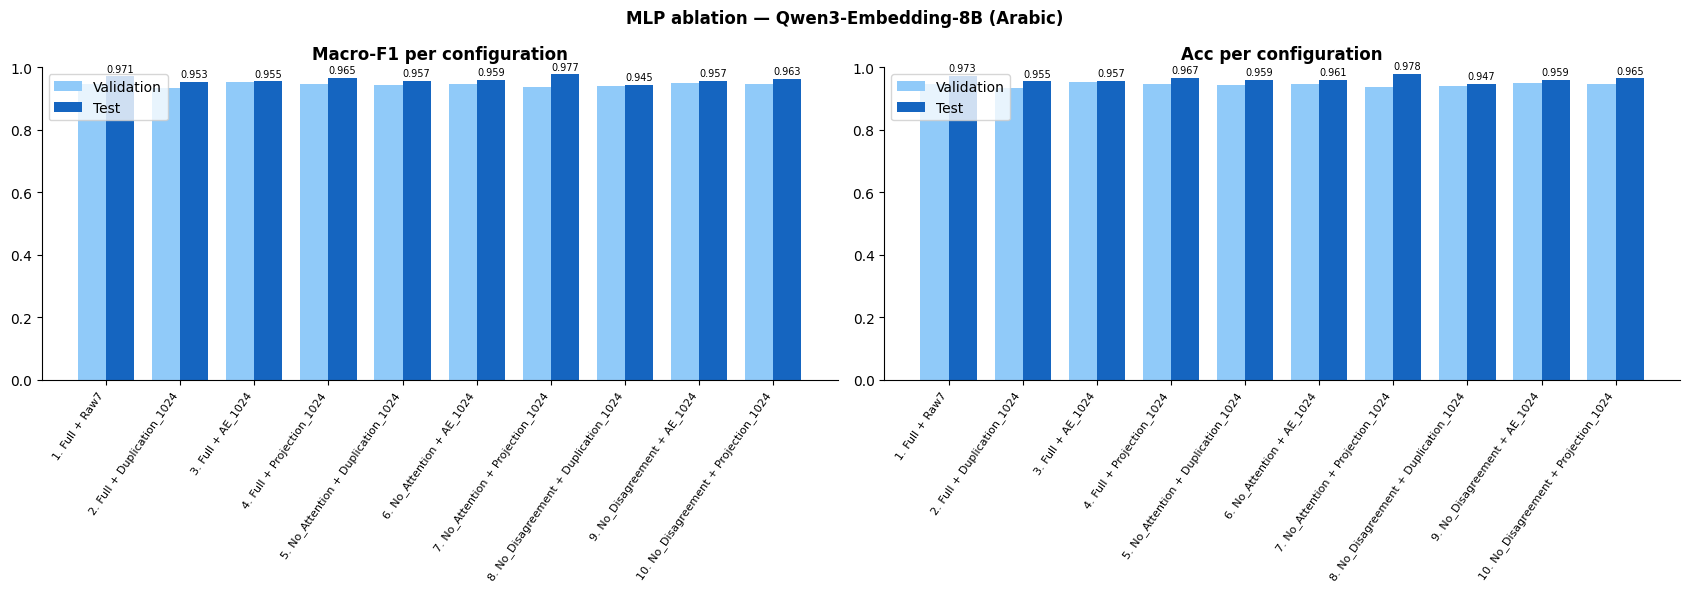

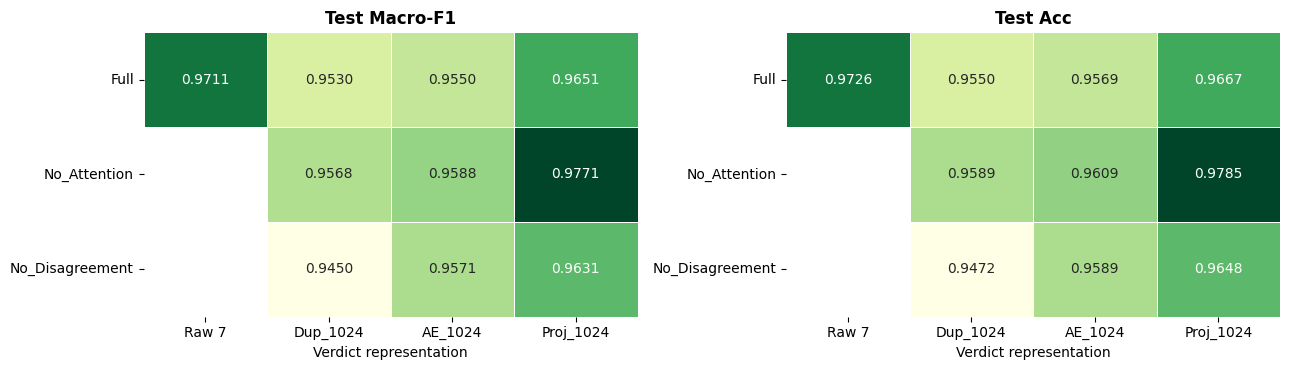

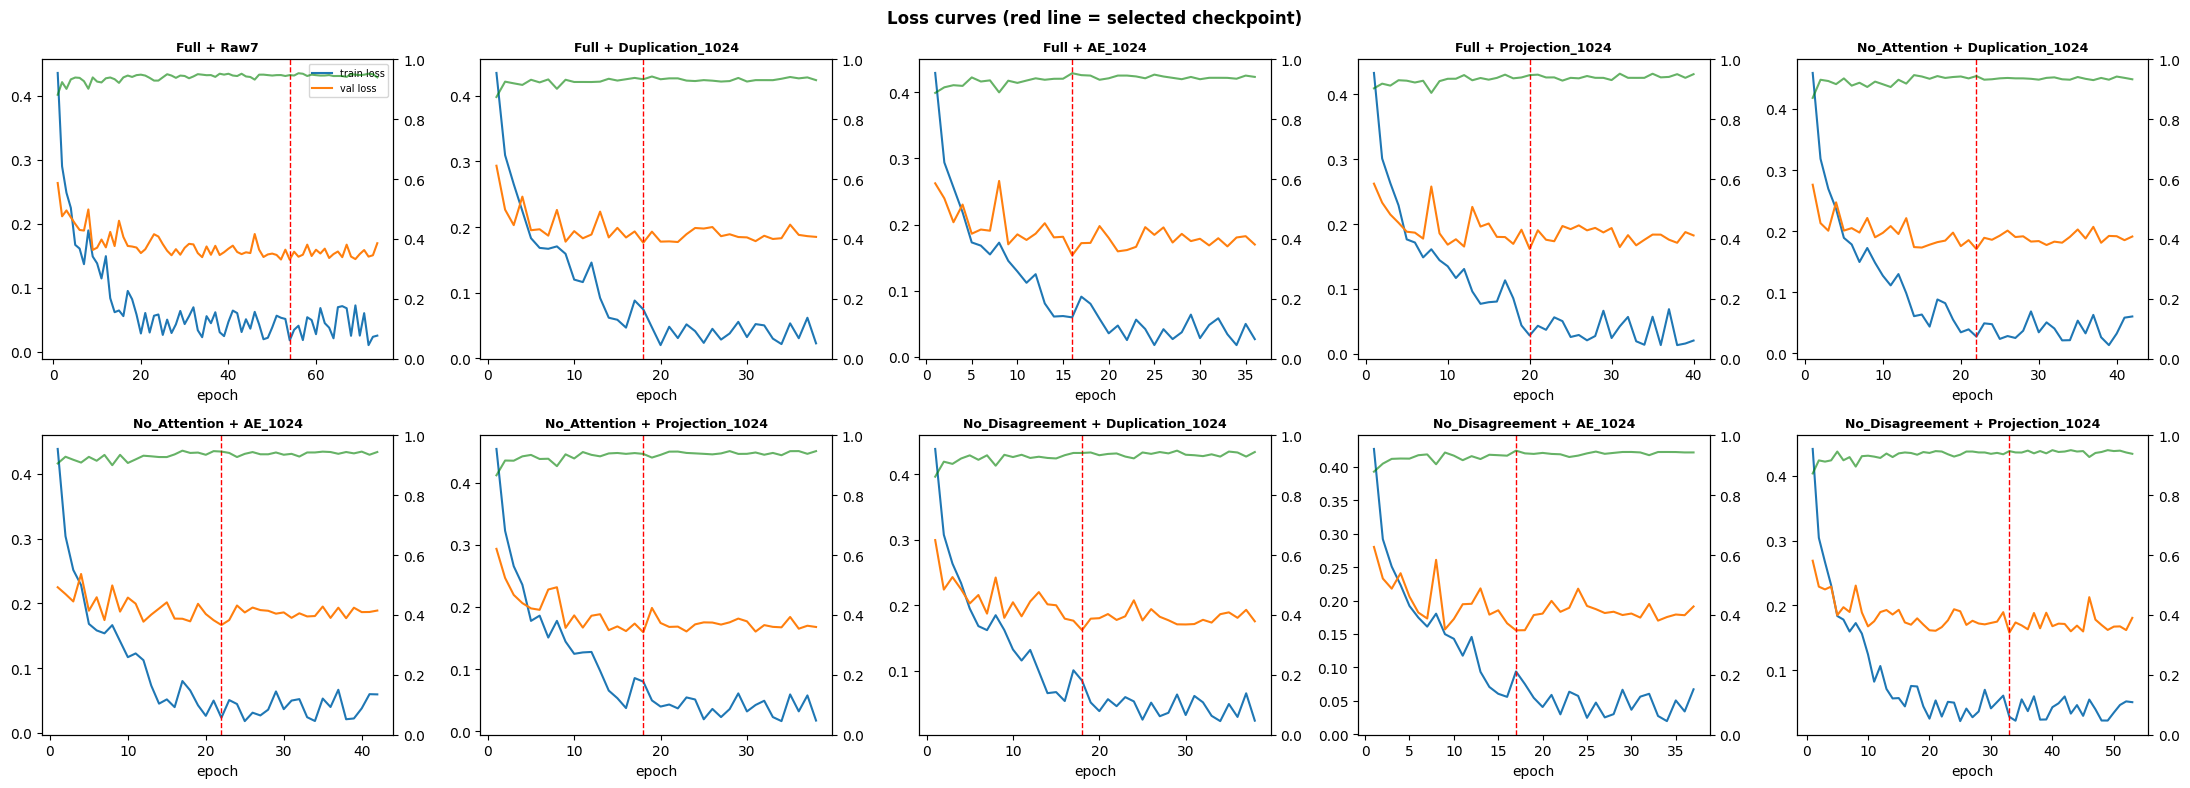

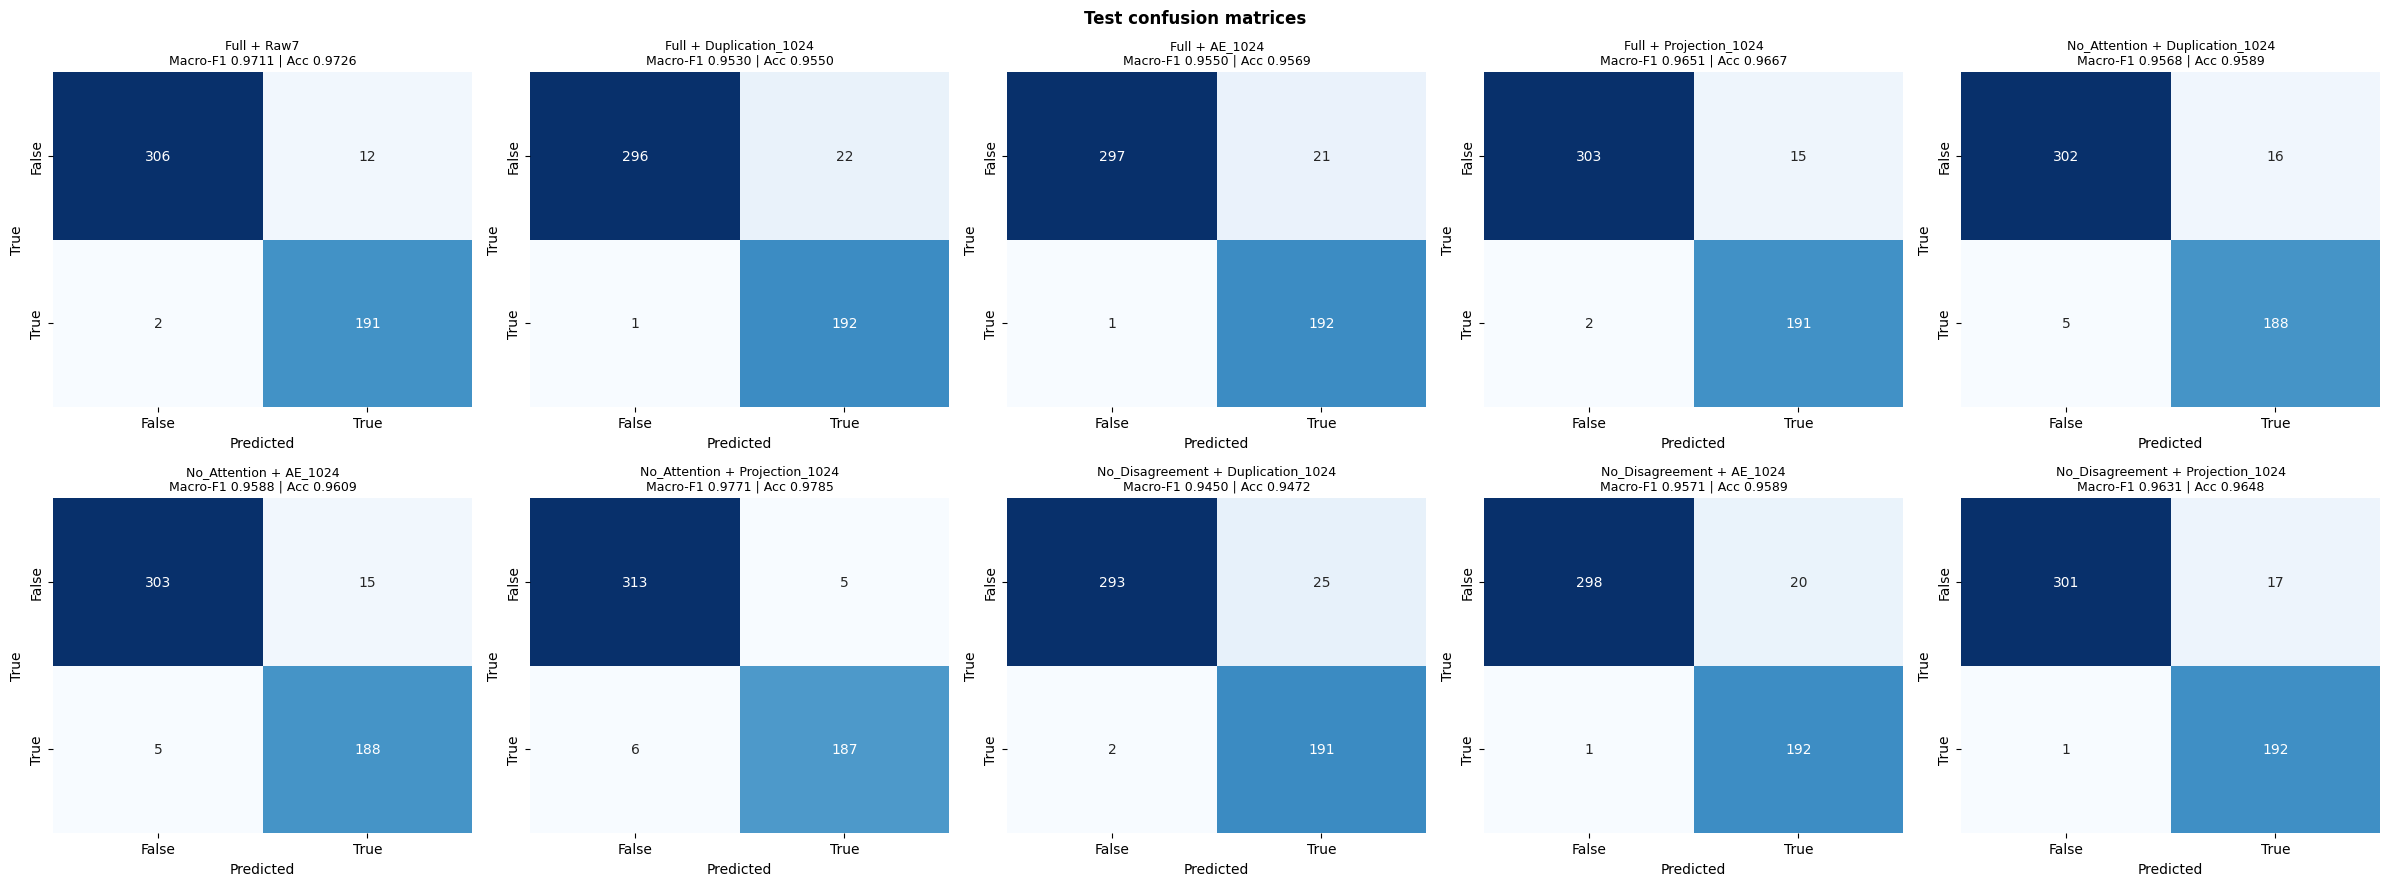

In [21]:
if ALL_RESULTS:
    # (a) Macro-F1 and Accuracy per configuration
    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    x = np.arange(len(RES)); w = 0.38
    for ax, metric in zip(axes, ["Macro-F1", "Acc"]):
        b1 = ax.bar(x - w/2, RES[f"Val {metric}"],  w, label="Validation", color="#90caf9")
        b2 = ax.bar(x + w/2, RES[f"Test {metric}"], w, label="Test",       color="#1565c0")
        ax.bar_label(b2, fmt="%.3f", fontsize=7, padding=2)
        ax.set_xticks(x); ax.set_xticklabels([f"{i}. {c}" for i, c in zip(RES["#"], RES["Configuration"])],
                                             rotation=55, ha="right", fontsize=8)
        ax.set_ylim(0, 1); ax.set_title(f"{metric} per configuration", fontweight="bold"); ax.legend()
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("MLP ablation — Qwen3-Embedding-8B (Arabic)", fontweight="bold"); fig.tight_layout()
    fig.savefig(f"{PLOTS_DIR}/ablation_bars.png", dpi=130, bbox_inches="tight"); plt.show()

    # (b) Matrix heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    for ax, k in zip(axes, ["Test Macro-F1", "Test Acc"]):
        sns.heatmap(MATS[k], annot=True, fmt=".4f", cmap="YlGn", cbar=False, ax=ax, linewidths=.5)
        ax.set_title(k, fontweight="bold"); ax.set_xlabel("Verdict representation"); ax.set_ylabel("")
    fig.tight_layout(); fig.savefig(f"{PLOTS_DIR}/ablation_matrix.png", dpi=130, bbox_inches="tight"); plt.show()

    # (c) Training curves
    fig, axes = plt.subplots(2, 5, figsize=(22, 8)); axes = axes.ravel()
    for ax, r in zip(axes, sorted(ALL_RESULTS, key=lambda r: r["name"])):
        h = r["history"]; ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], label="train loss"); ax.plot(ep, h["val_loss"], label="val loss")
        ax2 = ax.twinx(); ax2.plot(ep, h["val_macro_f1"], color="green", alpha=.6, label="val Macro-F1")
        ax2.set_ylim(0, 1); ax.axvline(r["best_epoch"], color="red", ls="--", lw=1)
        ax.set_title(r["display"], fontsize=9, fontweight="bold"); ax.set_xlabel("epoch")
    axes[0].legend(fontsize=7, loc="upper right")
    fig.suptitle("Loss curves (red line = selected checkpoint)", fontweight="bold"); fig.tight_layout()
    fig.savefig(f"{PLOTS_DIR}/loss_curves.png", dpi=110, bbox_inches="tight"); plt.show()

    # (d) Test confusion matrices
    fig, axes = plt.subplots(2, 5, figsize=(24, 9)); axes = axes.ravel()
    for ax, r in zip(axes, sorted(ALL_RESULTS, key=lambda r: r["name"])):
        m = r["metrics"]["test"]
        sns.heatmap(np.array(m["confusion_matrix"]), annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax.set_title(f"{r['display']}\nMacro-F1 {m['macro_f1']:.4f} | Acc {m['accuracy']:.4f}", fontsize=9)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    fig.suptitle("Test confusion matrices", fontweight="bold"); fig.tight_layout()
    fig.savefig(f"{PLOTS_DIR}/test_confusion_matrices.png", dpi=110, bbox_inches="tight"); plt.show()

## 16. Paper Table (LaTeX) & Output Manifest

In [22]:
if ALL_RESULTS:
    best_t, best_a = RES["Test Macro-F1"].max(), RES["Test Acc"].max()
    fmt = lambda v, b: (r"\textbf{%.4f}" % v) if abs(v - b) < 1e-12 else "%.4f" % v
    lines = [r"\begin{table}[t]", r"\centering",
             r"\caption{MLP ablation on the Arabic test set (Qwen3-Embedding-8B, seed 42).}",
             r"\label{tab:mlp-ablation}", r"\begin{tabular}{rlrcc}", r"\hline",
             r"\# & Configuration & Dim & Macro-F1 & Acc. \\", r"\hline"]
    for _, r in RES.iterrows():
        cfg = r["Configuration"].replace("_", r"\_")
        lines.append(f"{r['#']} & {cfg} & {r['Input dim']} & {fmt(r['Test Macro-F1'], best_t)} & "
                     f"{fmt(r['Test Acc'], best_a)} \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{table}"]
    with open(f"{OUTPUT_DIR}/mlp_ablation_table.tex", "w") as f: f.write("\n".join(lines))
    print("\n".join(lines))

print("\n── Output files ──")
for root, _, files in os.walk(OUTPUT_DIR):
    if "/." in root: continue
    for fn in sorted(files):
        p = os.path.join(root, fn)
        print(f"  {os.path.relpath(p, OUTPUT_DIR):<70} {os.path.getsize(p) / 1e6:>10.2f} MB")

\begin{table}[t]
\centering
\caption{MLP ablation on the Arabic test set (Qwen3-Embedding-8B, seed 42).}
\label{tab:mlp-ablation}
\begin{tabular}{rlrcc}
\hline
\# & Configuration & Dim & Macro-F1 & Acc. \\
\hline
1 & Full + Raw7 & 12295 & 0.9711 & 0.9726 \\
2 & Full + Duplication\_1024 & 13312 & 0.9530 & 0.9550 \\
3 & Full + AE\_1024 & 13312 & 0.9550 & 0.9569 \\
4 & Full + Projection\_1024 & 13312 & 0.9651 & 0.9667 \\
5 & No\_Attention + Duplication\_1024 & 9216 & 0.9568 & 0.9589 \\
6 & No\_Attention + AE\_1024 & 9216 & 0.9588 & 0.9609 \\
7 & No\_Attention + Projection\_1024 & 9216 & \textbf{0.9771} & \textbf{0.9785} \\
8 & No\_Disagreement + Duplication\_1024 & 9216 & 0.9450 & 0.9472 \\
9 & No\_Disagreement + AE\_1024 & 9216 & 0.9571 & 0.9589 \\
10 & No\_Disagreement + Projection\_1024 & 9216 & 0.9631 & 0.9648 \\
\hline
\end{tabular}
\end{table}

── Output files ──
  __notebook__.ipynb                                                           0.85 MB
  data_diagnostics.json           

## 17. Notes
* **Fixed from earlier notebooks:** `TRACE_TEXT_FIELD` is now `Reasoning_traces`. Previously every item had a single `[NO TRACE]` embedding, so attention and disagreement carried no information. §6.1 now asserts per-item trace counts. The AE encoder is deep-copied per experiment (it was previously shared and mutated across runs).
* **AE_1024:** pre-trained on train verdict features only, with the epoch selected by validation reconstruction MSE (no labels used anywhere). The encoder is frozen in all three AE configurations.
* **Proj_1024:** BatchNorm + ReLU (as in the methodology), trained end-to-end with the classifier.
* **Label space:** targets are the gold classes present in train (`TARGET_LABELS="auto"`). The Arabic set has **no gold "Conflicting"** in any split, so the head is 2-way (False/True), the class weights are `N/(2·n_c)`, and Macro-F1 is averaged over False and True. With a 3-way metric the empty class would score F1 = 0 and cap Macro-F1 at 0.667. "Conflicting" remains a trace vote type inside the 7 verdict features.
* **Not in this phase:** XGBoost. Saved `models/*.pt` contain the trained attention and projection weights for later reuse.